# AAPL Trend Labeling and Window Construction

## Objective

Construct supervised learning samples using the trend-labeling
method described in the referenced research paper.

The paper defines trend using the difference between the average
price over a future K-day window and the average price over a
previous K-day window.

For this implementation:

- K = 3 trading days
- Prediction classes = Rise / Fall
- Input window = 22 trading days

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
features = pd.read_csv(
    "../data/processed/AAPL_features.csv",
    index_col=0,
    parse_dates=True
)

features.head()

,Open,High,Low,Close,Volume,MA5,EMA20,MACD,ATR,ROC
Date,,,,,,,,,,
2025-09-23,255.880005,257.339996,253.580002,254.429993,60275200,246.575998,238.934624,4.618355,4.956985,6.149606
2025-09-24,255.220001,255.740005,251.039993,252.309998,42303700,249.239996,240.208469,5.088564,4.938630,6.066081
2025-09-25,253.210007,257.170013,251.710007,256.869995,55202100,253.037994,241.795281,5.762732,4.975871,9.609553
2025-09-26,254.100006,257.600006,253.779999,255.460007,46076300,255.029996,243.096683,6.112776,4.893310,12.641657
2025-09-29,254.559998,255.000000,253.009995,254.429993,40127700,254.699997,244.176046,6.235200,4.718788,10.607309


In [10]:
print("Shape:", features.shape)
print("Date range:", features.index.min(), "→", features.index.max())

Shape: (226, 10)
Date range: 2025-09-23 00:00:00 → 2026-08-17 00:00:00


### Label Price

The closing price is used to calculate the past and future K-day
averages.

This provides a consistent daily price series for defining the
short-term trend while keeping the model inputs within the
assessment's OHLC constraint.

In [11]:
K = 3

print("Prediction horizon K:", K)

Prediction horizon K: 3


In [12]:
close = features["Close"]

past_avg = close.rolling(window=K).mean()

future_avg = close.shift(-K).rolling(window=K).mean()

In [13]:
label_data = features[["Close"]].copy()

past_values = []
future_values = []

for i in range(len(label_data)):
    
    past_start = i - K + 1
    past_end = i + 1
    
    future_start = i + 1
    future_end = i + K + 1
    
    if past_start < 0 or future_end > len(label_data):
        past_values.append(np.nan)
        future_values.append(np.nan)
        continue
    
    past_window = label_data["Close"].iloc[past_start:past_end]
    future_window = label_data["Close"].iloc[future_start:future_end]
    
    past_values.append(past_window.mean())
    future_values.append(future_window.mean())

label_data["past_avg"] = past_values
label_data["future_avg"] = future_values

In [14]:
label_data["slope"] = (
    label_data["future_avg"]
    - label_data["past_avg"]
)

In [15]:
label_data.head(10)

,Close,past_avg,future_avg,slope
Date,,,,
2025-09-23,254.429993,NaN,NaN,NaN
2025-09-24,252.309998,NaN,NaN,NaN
2025-09-25,256.869995,254.536662,254.840001,0.303340
2025-09-26,255.460007,254.880000,254.836665,-0.043335
2025-09-29,254.429993,255.586665,255.736669,0.150004
2025-09-30,254.630005,254.840001,256.866664,2.026662
2025-10-01,255.449997,254.836665,257.279999,2.443334
2025-10-02,257.130005,255.736669,257.063334,1.326665
2025-10-03,258.019989,256.866664,257.076670,0.210007


In [16]:
label_data.tail(10)

,Close,past_avg,future_avg,slope
Date,,,,
2026-08-04,309.380005,307.236674,312.246663,5.009989
2026-08-05,311.000000,307.933339,311.333333,3.399994
2026-08-06,312.410004,310.930003,308.833333,-2.096670
2026-08-07,313.329987,312.246663,305.140004,-7.106659
2026-08-10,308.260010,311.333333,304.140004,-7.193329
2026-08-11,304.910004,308.833333,304.480001,-4.353333
2026-08-12,302.250000,305.140004,305.276672,0.136668
2026-08-13,305.260010,NaN,NaN,NaN
2026-08-14,305.929993,NaN,NaN,NaN


In [17]:
i = K + 10

date = label_data.index[i]

past_window = label_data["Close"].iloc[i-K+1:i+1]
future_window = label_data["Close"].iloc[i+1:i+K+1]

print("Date:", date)

print("\nPast window:")
print(past_window)

print("\nFuture window:")
print(future_window)

print("\nPast average:", past_window.mean())
print("Future average:", future_window.mean())
print("Slope:", future_window.mean() - past_window.mean())

Date: 2025-10-10 00:00:00

Past window:
Date
2025-10-08    258.059998
2025-10-09    254.039993
2025-10-10    245.270004
Name: Close, dtype: float64

Future window:
Date
2025-10-13    247.660004
2025-10-14    247.770004
2025-10-15    249.339996
Name: Close, dtype: float64

Past average: 252.4566650390625
Future average: 248.2566680908203
Slope: -4.1999969482421875


In [18]:
print("\nStored values:")
print("Past average:", label_data.iloc[i]["past_avg"])
print("Future average:", label_data.iloc[i]["future_avg"])
print("Slope:", label_data.iloc[i]["slope"])


Stored values:
Past average: 252.4566650390625
Future average: 248.2566680908203
Slope: -4.1999969482421875


In [19]:
slope_std = label_data["slope"].std()

print("Slope standard deviation:", slope_std)

Slope standard deviation: 6.8664128441068035


In [20]:
label_data["trend"] = np.where(
    label_data["slope"] > 0,
    "Rise",
    "Fall"
)

In [21]:
label_data[["Close", "past_avg", "future_avg", "slope", "trend"]].head(15)

,Close,past_avg,future_avg,slope,trend
Date,,,,,
2025-09-23,254.429993,NaN,NaN,NaN,Fall
2025-09-24,252.309998,NaN,NaN,NaN,Fall
2025-09-25,256.869995,254.536662,254.840001,0.303340,Rise
2025-09-26,255.460007,254.880000,254.836665,-0.043335,Fall
2025-09-29,254.429993,255.586665,255.736669,0.150004,Rise
2025-09-30,254.630005,254.840001,256.866664,2.026662,Rise
2025-10-01,255.449997,254.836665,257.279999,2.443334,Rise
2025-10-02,257.130005,255.736669,257.063334,1.326665,Rise
2025-10-03,258.019989,256.866664,257.076670,0.210007,Rise


In [22]:
label_data = label_data.dropna(
    subset=["past_avg", "future_avg", "slope"]
).copy()

In [23]:
print("Rows after labeling:", len(label_data))
print("Missing labels:", label_data["trend"].isna().sum())

Rows after labeling: 221
Missing labels: 0


In [24]:
class_counts = label_data["trend"].value_counts()

print(class_counts)

print("\nClass percentages:")
print(
    label_data["trend"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

trend
Rise    124
Fall     97
Name: count, dtype: int64

Class percentages:
trend
Rise    56.11
Fall    43.89
Name: proportion, dtype: float64


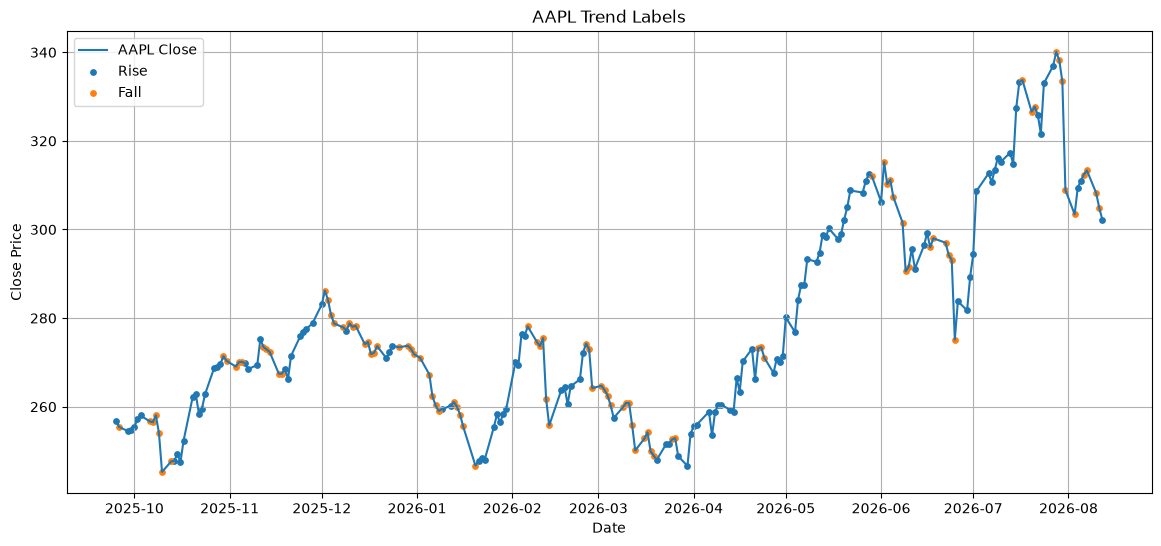

In [25]:
plt.figure(figsize=(14, 6))

rise = label_data["trend"] == "Rise"
fall = label_data["trend"] == "Fall"

plt.plot(
    label_data.index,
    label_data["Close"],
    label="AAPL Close"
)

plt.scatter(
    label_data.index[rise],
    label_data.loc[rise, "Close"],
    label="Rise",
    s=15
)

plt.scatter(
    label_data.index[fall],
    label_data.loc[fall, "Close"],
    label="Fall",
    s=15
)

plt.title("AAPL Trend Labels")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.show()

In [26]:
labeled_path = "../data/processed/AAPL_labeled.csv"

label_data.to_csv(labeled_path)

print(f"Saved labeled dataset to: {labeled_path}")

Saved labeled dataset to: ../data/processed/AAPL_labeled.csv


In [27]:
WINDOW_SIZE = 22

print("Input window:", WINDOW_SIZE)
print("Prediction horizon:", K)

Input window: 22
Prediction horizon: 3


In [28]:
model_features = [
    "Open",
    "High",
    "Low",
    "Close",
    "MA5",
    "EMA20",
    "MACD",
    "ATR",
    "ROC"
]

In [29]:
dataset = features.join(
    label_data[["past_avg", "future_avg", "slope", "trend"]],
    how="inner"
)

dataset.head()

,Open,High,Low,Close,Volume,MA5,EMA20,MACD,ATR,ROC,past_avg,future_avg,slope,trend
Date,,,,,,,,,,,,,,
2025-09-25,253.210007,257.170013,251.710007,256.869995,55202100,253.037994,241.795281,5.762732,4.975871,9.609553,254.536662,254.840001,0.303340,Rise
2025-09-26,254.100006,257.600006,253.779999,255.460007,46076300,255.029996,243.096683,6.112776,4.893310,12.641657,254.880000,254.836665,-0.043335,Fall
2025-09-29,254.559998,255.000000,253.009995,254.429993,40127700,254.699997,244.176046,6.235200,4.718788,10.607309,255.586665,255.736669,0.150004,Rise
2025-09-30,254.860001,255.919998,253.110001,254.630005,37704300,254.739999,245.171661,6.276015,4.582446,8.783696,254.840001,256.866664,2.026662,Rise
2025-10-01,255.039993,258.790009,254.929993,255.449997,48713900,255.367999,246.150550,6.301884,4.552272,7.921420,254.836665,257.279999,2.443334,Rise


In [30]:
print("Combined dataset shape:", dataset.shape)
print("Date range:", dataset.index.min(), "→", dataset.index.max())

Combined dataset shape: (221, 14)
Date range: 2025-09-25 00:00:00 → 2026-08-12 00:00:00


In [31]:
X = []
y = []
dates = []

for i in range(WINDOW_SIZE - 1, len(dataset)):
    
    window = dataset[model_features].iloc[
        i - WINDOW_SIZE + 1 : i + 1
    ].values
    
    label = dataset["trend"].iloc[i]
    date = dataset.index[i]
    
    X.append(window)
    y.append(label)
    dates.append(date)

X = np.array(X)
y = np.array(y)
dates = pd.DatetimeIndex(dates)

In [32]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("dates shape:", dates.shape)

X shape: (200, 22, 9)
y shape: (200,)
dates shape: (200,)


In [33]:
sample_index = 0

print("Sample date:", dates[sample_index])
print("Sample label:", y[sample_index])

print("\nInput shape:")
print(X[sample_index].shape)

print("\nInput:")
display(
    pd.DataFrame(
        X[sample_index],
        columns=model_features
    )
)

Sample date: 2025-10-24 00:00:00
Sample label: Rise

Input shape:
(22, 9)

Input:


,Open,High,Low,Close,MA5,EMA20,MACD,ATR,ROC
0,253.210007,257.170013,251.710007,256.869995,253.037994,241.795281,5.762732,4.975871,9.609553
1,254.100006,257.600006,253.779999,255.460007,255.029996,243.096683,6.112776,4.893310,12.641657
2,254.559998,255.000000,253.009995,254.429993,254.699997,244.176046,6.235200,4.718788,10.607309
3,254.860001,255.919998,253.110001,254.630005,254.739999,245.171661,6.276015,4.582446,8.783696
4,255.039993,258.790009,254.929993,255.449997,255.367999,246.150550,6.301884,4.552272,7.921420
5,256.579987,258.179993,254.149994,257.130005,255.420001,247.196213,6.384353,4.514966,7.969772
6,254.669998,259.239990,253.949997,258.019989,255.931998,248.227049,6.447205,4.570325,7.962669
7,257.989990,259.070007,255.050003,256.690002,256.384000,249.033044,6.316880,4.531017,7.907347
8,256.809998,257.399994,255.429993,256.480011,256.754001,249.742279,6.126034,4.348087,4.472510
9,256.519989,258.519989,256.109985,258.059998,257.276001,250.534443,6.032738,4.209653,0.773200


In [34]:
print("First sample date:", dates[0])
print("Last sample date:", dates[-1])

print(
    "Dates chronological:",
    dates.is_monotonic_increasing
)

First sample date: 2025-10-24 00:00:00
Last sample date: 2026-08-12 00:00:00
Dates chronological: True


In [35]:
print("=" * 60)
print("SUPERVISED DATASET SUMMARY")
print("=" * 60)

print(f"Asset: AAPL")
print(f"Input window: {WINDOW_SIZE} trading days")
print(f"Prediction horizon: {K} trading days")
print(f"Features per timestep: {len(model_features)}")
print(f"Samples: {len(X)}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

print("\nClasses:")
unique, counts = np.unique(y, return_counts=True)

for label, count in zip(unique, counts):
    print(f"  {label}: {count}")

SUPERVISED DATASET SUMMARY
Asset: AAPL
Input window: 22 trading days
Prediction horizon: 3 trading days
Features per timestep: 9
Samples: 200
X shape: (200, 22, 9)
y shape: (200,)

Classes:
  Fall: 90
  Rise: 110


In [36]:
np.save(
    "../data/processed/X_sequences.npy",
    X
)

np.save(
    "../data/processed/y_labels.npy",
    y
)

dates.to_series().to_csv(
    "../data/processed/sample_dates.csv",
    header=["date"]
)

print("Saved sequence dataset.")

Saved sequence dataset.
